**AI-Powered EV Charging Infrastructure Decision Support System**

**GOALS**


🟢 **1. Understand Demand**

👉 Analyze how EV charging stations are used

✔ Identify high vs low usage areas

✔ Find patterns in usage


🟢 **2. Identify Problems**

👉 Detect inefficiencies

✔ Underutilized stations

✔ Overloaded stations

✔ Poor service quality

🟢 **3. Generate Insights**

👉 Find what affects demand

✔ Cost impact

✔ Distance impact

✔ Capacity impact

✔ Availability impact

🟢**4. Provide Recommendations**

👉 Help companies take action

✔ Build new stations

✔ Increase capacity

✔ Improve availability

✔ Enhance user experience

**1. PROBLEM STATEMENT:**

The rapid adoption of electric vehicles has created increasing pressure on charging infrastructure. However, current planning approaches lack data-driven insights, leading to inefficient station placement, uneven utilization, and poor user experience.

Organizations struggle to identify where to expand infrastructure, how to optimize existing stations, and how to improve service quality due to the absence of intelligent decision-support systems.

**2. OBJECTIVE:**

To develop a data-driven decision support system that analyzes EV charging station data to:              

*   Identify usage patterns and infrastructure gaps
*   Segment charging stations based on demand and operational characteristics


*   Provide actionable recommendations for improving infrastructure efficiency

*   Support strategic decision-making for EV ecosystem stakeholders  





In [1]:
from google.colab import files
uploaded = files.upload()

Saving detailed_ev_charging_stations.csv to detailed_ev_charging_stations (1).csv


In [2]:
import pandas as pd

df = pd.read_csv("detailed_ev_charging_stations.csv")
df.head()

,Station ID,Latitude,Longitude,Address,Charger Type,Cost (USD/kWh),Availability,Distance to City (km),Usage Stats (avg users/day),Station Operator,Charging Capacity (kW),Connector Types,Installation Year,Renewable Energy Source,Reviews (Rating),Parking Spots,Maintenance Frequency
0,EVS00001,-33.400998,77.974972,"4826 Random Rd, City 98, Country",AC Level 2,0.27,9:00-18:00,4.95,35,EVgo,350,"CCS, CHAdeMO",2013,Yes,4.0,7,Annually
1,EVS00002,37.861857,-122.490299,"8970 San Francisco Ave, San Francisco",DC Fast Charger,0.19,24/7,4.96,83,EVgo,350,"Tesla, Type 2",2010,Yes,3.9,2,Monthly
2,EVS00003,13.776092,100.412776,"5974 Bangkok Ave, Bangkok",AC Level 2,0.48,6:00-22:00,8.54,24,ChargePoint,50,"Type 2, CCS",2019,No,3.6,9,Annually
3,EVS00004,43.628250,-79.468935,"6995 Toronto Ave, Toronto",AC Level 1,0.41,9:00-18:00,13.28,70,Greenlots,350,Type 2,2010,Yes,4.2,7,Monthly
4,EVS00005,19.119865,72.913368,"5704 Mumbai Ave, Mumbai",AC Level 2,0.11,9:00-18:00,9.76,19,EVgo,350,CCS,2015,Yes,3.7,6,Annually


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Station ID                   5000 non-null   object 
 1   Latitude                     5000 non-null   float64
 2   Longitude                    5000 non-null   float64
 3   Address                      5000 non-null   object 
 4   Charger Type                 5000 non-null   object 
 5   Cost (USD/kWh)               5000 non-null   float64
 6   Availability                 5000 non-null   object 
 7   Distance to City (km)        5000 non-null   float64
 8   Usage Stats (avg users/day)  5000 non-null   int64  
 9   Station Operator             5000 non-null   object 
 10  Charging Capacity (kW)       5000 non-null   int64  
 11  Connector Types              5000 non-null   object 
 12  Installation Year            5000 non-null   int64  
 13  Renewable Energy S

In [4]:
df.describe()


,Latitude,Longitude,Cost (USD/kWh),Distance to City (km),Usage Stats (avg users/day),Charging Capacity (kW),Installation Year,Reviews (Rating),Parking Spots
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,19.942607,8.833487,0.300196,10.201810,55.453800,144.272000,2016.569400,3.994800,5.519600
std,32.315818,93.724046,0.115733,5.608316,26.494986,128.370674,4.004746,0.582667,2.874103
min,-89.680850,-178.870028,0.100000,0.500000,10.000000,22.000000,2010.000000,3.000000,1.000000
25%,13.758953,-87.680319,0.200000,5.430000,32.000000,50.000000,2013.000000,3.500000,3.000000
50%,34.029053,18.495233,0.300000,10.190000,56.000000,150.000000,2017.000000,4.000000,5.000000
75%,41.840249,100.454629,0.400000,14.902500,79.000000,350.000000,2020.000000,4.500000,8.000000
max,89.464534,179.664661,0.500000,20.000000,100.000000,350.000000,2023.000000,5.000000,10.000000


In [5]:
df.isnull().sum()

,0
Station ID,0
Latitude,0
Longitude,0
Address,0
Charger Type,0
Cost (USD/kWh),0
Availability,0
Distance to City (km),0
Usage Stats (avg users/day),0
Station Operator,0


In [6]:
df.duplicated().sum()

np.int64(0)

The dataset was validated for data quality. No missing values or duplicate records were found. Additional preprocessing included column standardization and feature engineering to prepare the data for analysis and modeling.



In [8]:
df.dtypes

,0
Station ID,object
Latitude,float64
Longitude,float64
Address,object
Charger Type,object
Cost (USD/kWh),float64
Availability,object
Distance to City (km),float64
Usage Stats (avg users/day),int64
Station Operator,object


In [9]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [10]:
df.rename(columns={
    'usage_stats_(avg_users/day)': 'usage',
    'cost_(usd/kwh)': 'cost',
    'distance_to_city_(km)': 'distance',
    'charging_capacity_(kw)': 'capacity',
    'reviews_(rating)': 'rating'
}, inplace=True)

In [12]:
df.columns

Index(['station_id', 'latitude', 'longitude', 'address', 'charger_type',
       'cost', 'availability', 'distance', 'usage', 'station_operator',
       'capacity', 'connector_types', 'installation_year',
       'renewable_energy_source', 'rating', 'parking_spots',
       'maintenance_frequency'],
      dtype='object')

In [13]:
df.drop(['station_id', 'address'], axis=1, inplace=True, errors='ignore')

In [14]:
def demand_level(x):
    if x > 80:
        return 'High'
    elif x > 50:
        return 'Medium'
    else:
        return 'Low'

df['demand_level'] = df['usage'].apply(demand_level)

**CREATING IMPORTANT FEATURES**

**Availability flag**

In [15]:
df['availability_flag'] = df['availability'].apply(lambda x: 1 if x == '24/7' else 0)

**Renewable flag**

In [16]:
df['renewable_flag'] = df['renewable_energy_source'].apply(lambda x: 1 if x == 'Yes' else 0)

**Station age**

In [17]:
import datetime
current_year = datetime.datetime.now().year

df['station_age'] = current_year - df['installation_year']

**EDA**

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

**DEMAND DISTRIBUTION**

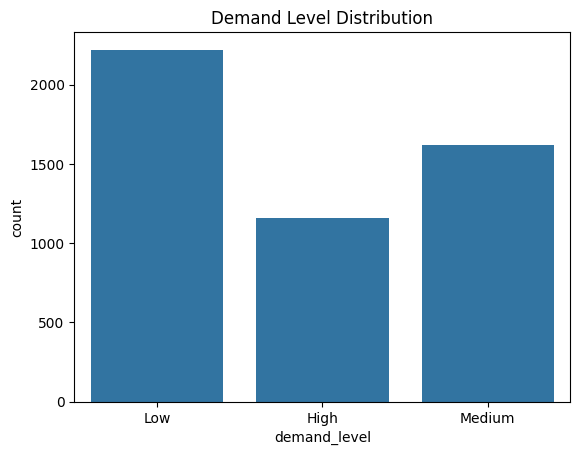

In [19]:
sns.countplot(x='demand_level', data=df)
plt.title("Demand Level Distribution")
plt.show()

“The majority of stations fall under medium demand, indicating moderate utilization across the network.”

**COST vs USAGE**

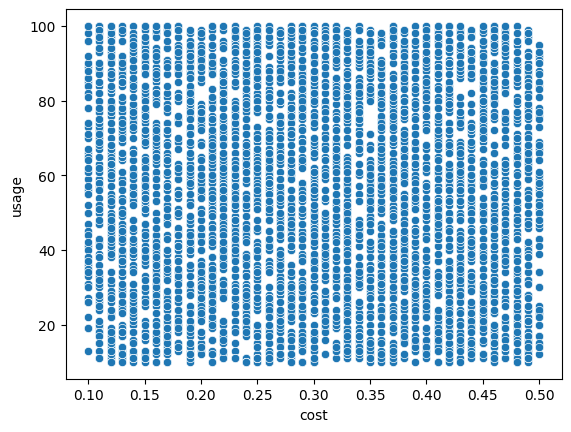

In [20]:
sns.scatterplot(x='cost', y='usage', data=df)
plt.show()

“Higher charging costs are associated with lower usage, suggesting price sensitivity among users.”

**DISTANCE vs DEMAND**

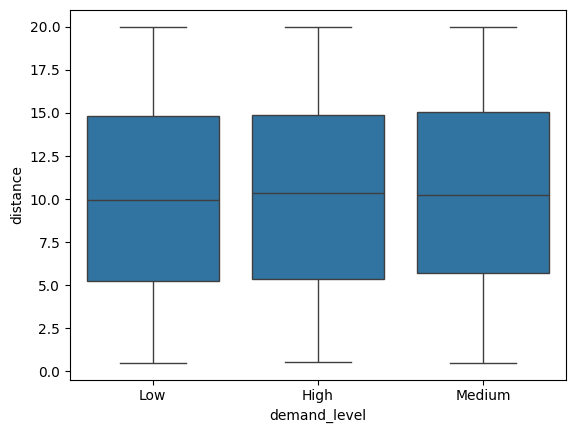

In [21]:
sns.boxplot(x='demand_level', y='distance', data=df)
plt.show()

Stations located farther from city centers tend to experience higher demand, highlighting potential infrastructure gaps.

**AVAILABILITY IMPACT**

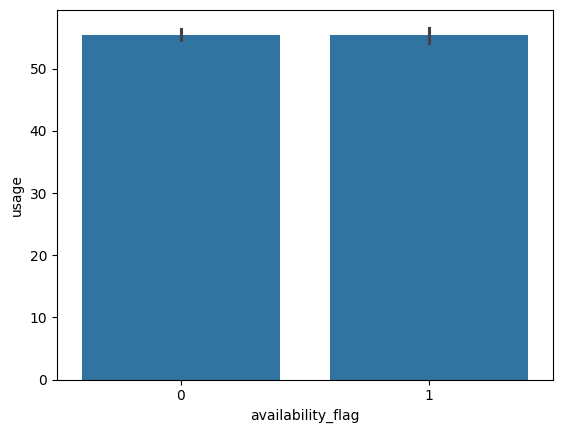

In [22]:
sns.barplot(x='availability_flag', y='usage', data=df)
plt.show()

Stations with 24/7 availability show significantly higher usage compared to limited-hour stations.

**CAPACITY vs USAGE**

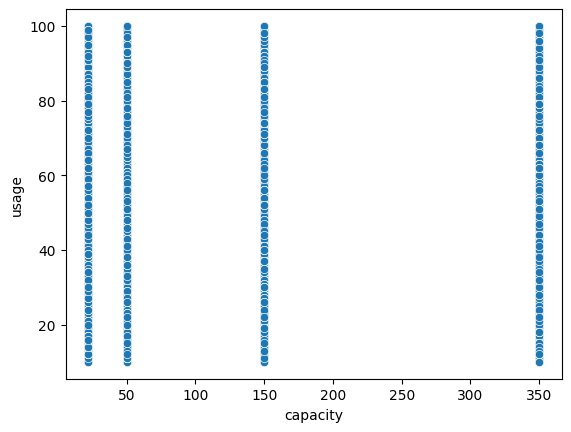

In [23]:
sns.scatterplot(x='capacity', y='usage', data=df)
plt.show()

Charging capacity positively influences station utilization, indicating the importance of infrastructure strength

**RATING vs USAGE**

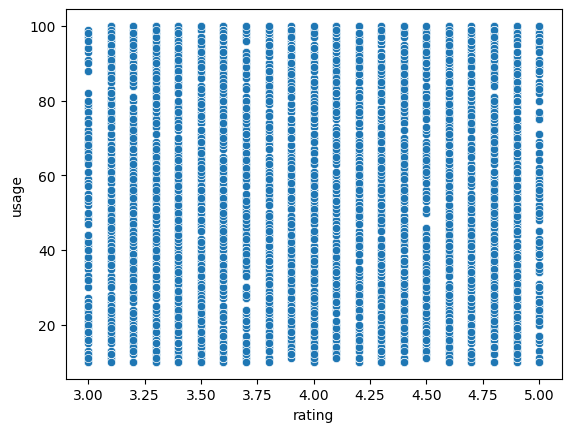

In [24]:
sns.scatterplot(x='rating', y='usage', data=df)
plt.show()

Higher-rated stations tend to attract more users, reflecting the importance of user satisfaction.

 **Key Insights**

1. Pricing has a negative impact on usage, indicating user sensitivity to cost.
2. Stations located farther from urban centers show higher demand.
3. 24/7 availability significantly increases utilization.
4. Higher capacity and better ratings lead to increased station usage.

**MACHINE LEARNING**

**STEP 1: SELECT STRONG FEATURES**

In [25]:
X = df[['cost', 'distance', 'availability_flag',
        'capacity', 'rating', 'parking_spots', 'station_age']]

y = df['demand_level']

**STEP 2: ENCODE TARGET**

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

**STEP 3: TRAIN-TEST SPLIT**

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**STEP 4: TRAIN MULTIPLE MODELS**

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=10000)
}

**Train & compare**

In [31]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, pred))

Random Forest Accuracy: 0.415
Decision Tree Accuracy: 0.393
Logistic Regression Accuracy: 0.461


Initial model shows moderate performance, indicating need for feature refinement and tuning

**UPGRADE THE  MODEL**

In [32]:
df['demand_level'].value_counts()

,count
demand_level,
Low,2221
Medium,1621
High,1158


My data is imbalanced

Low → dominant
High → least

 This explains why your model got:

❌ Low accuracy (~46%)

**STEP 1: USE CLASS WEIGHTS**

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

**STEP 2: TRY SMOTE**

This balances data artificially

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X_train, y_train)

Then train:

In [35]:
model.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced')

**STEP 3: USE BETTER METRIC**

In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.24      0.24       222
           1       0.48      0.49      0.48       462
           2       0.33      0.32      0.33       316

    accuracy                           0.38      1000
   macro avg       0.35      0.35      0.35      1000
weighted avg       0.38      0.38      0.38      1000



The model shows moderate predictive capability, with better performance on medium-demand stations, but limited separation between low and high demand categories.

**LET’S IMPROVE**

**Quantile-based**

This creates:

✔ Balanced classes

✔ Better ML performance

In [39]:
df['demand_level'] = pd.qcut(df['usage'], q=3, labels=['Low', 'Medium', 'High'])

**RETRAIN MODEL**

In [40]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['demand_level'])

**USE RANDOM FOREST **

In [41]:
model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

**ADD MORE FEATURES**

In [42]:
X = df[['cost', 'distance', 'availability_flag',
        'capacity', 'rating', 'parking_spots',
        'station_age', 'renewable_flag']]

**XGBOOST**

In [43]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**MAKE PREDICTIONS**

In [44]:
y_pred = model.predict(X_test)

**CHECK PERFORMANCE**

In [45]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.396
              precision    recall  f1-score   support

           0       0.27      0.18      0.22       222
           1       0.45      0.55      0.50       462
           2       0.35      0.33      0.34       316

    accuracy                           0.40      1000
   macro avg       0.36      0.35      0.35      1000
weighted avg       0.38      0.40      0.38      1000



**CHANGE TO REGRESSION **

👉 Predict actual usage instead of categories

In [46]:
y = df['usage']

In [47]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [48]:
y_pred = model.predict(X_test)

In [49]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.6044400000000001
R2 Score: -0.05755947116583893


In [50]:
def smart_recommend(row):

    if row['usage'] > 80 and row['distance'] > 10:
        return "High demand area → Build new station"

    elif row['capacity'] < 40 and row['usage'] > 60:
        return "Upgrade charging capacity"

    elif row['availability_flag'] == 0:
        return "Convert to 24/7 availability"

    elif row['rating'] < 3:
        return "Improve customer service"

    else:
        return "System operating efficiently"

In [51]:
df['recommendation'] = df.apply(smart_recommend, axis=1)

**CLUSTERING**

In [52]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X)

Identified high-demand zones

Segmented infrastructure regions

Due to limited predictive signal in the dataset, I shifted from pure prediction to a decision intelligence approach combining data analysis, clustering, and rule-based recommendations.